# 13. Linear algebra in Python

Refresher (or not): For the sake of brevity we'll say that a $m\times n$ matrix is a two dimensional array of numbers, the matrix coefficents.
The coefficients of the sum of two matrix is the matrices are the summ of their coefficients. Multiplying a matrix by a scalar consists in multipliying ots coefficient by the said scalar.

### Matrix vector product.

We can define a matrix to vector product by simply writing that if $\mathbf{F}$ has coefficient matrix $\mathbf{A}$, then 
$$\mathbf{F}(\mathbf{x}) := \mathbf{A}\mathbf{x}.$$

It quickly comes that if $\mathbf{A}$ is a $m \times n$ matrix and $\mathbf{x}$ is a $n$ vector (which is basically a $n \times 1$ matrix), then $\mathbf{A}\mathbf{x}$ is a $m \times 1$ matrix such that 
$$
\left[\mathbf{A}\mathbf{x}\right]_{i,j} = \sum_{k = 1}{n} A_{i,k} x_k
$$
which is simply the dot product of the $i^\mathrm{th}$ row of $\mathbf{A}$ with $\mathbf{x}$.

### Matrix product.

The product of 2 matrices $\mathbf{A}$ and $\mathbf{B}$ can be thought as the coefficient matrix of the linear application obtained by composing inear functions whose coefficients are $\mathbf{A}$ and $\mathbf{B}$.

This way, if $\mathbf{F}:\ \mathbb{R}^n \mapsto \mathbb{R}^p$ has for coefficients the $p\times n$ matrix $\mathbf{A}$ and $\mathbf{G}:\ \mathbb{R}^m \mapsto \mathbb{R}^p$ has for coefficients the $p\times m$ matrix $\mathbf{B}$, then $\mathbf{G} \circ \mathbf{F}$ has coefficient the $m \times n$ matrix $\mathbf{A}\mathbf{B}$ with
$$
\left[\mathbf{A}\mathbf{B}\right]_{i,j} = \sum_{k=1}^p A_{i,k} B_{k,j}.
$$



In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import scipy

## Matrices in python:
We saw that numpy has 2d arrays, which look like matrices. Addition, subtraction, and scalar multiplication work as expected but remember that numpy vectorizes all operations, so '*' is not the matrix-vector (or matrix-matrix) product:

In [3]:
A = np.array([[1,2,3],[4,5,6]])
B = np.array([[1,-1,1],[2,2,-1]])
b = np.array([1,0,-2])
c = np.array([[1], [0], [-2]])
print("All of this is OK")
print('A:\n',A)
print('B:\n',B)
print('A+B:\n',A+B)
print('2A:\n',2*A)
print('b:\n', b)
print('c:\n', c)

print("\nThis is not OK!")
print('A*b:\n',A*b)

All of this is OK
A:
 [[1 2 3]
 [4 5 6]]
B:
 [[ 1 -1  1]
 [ 2  2 -1]]
A+B:
 [[2 1 4]
 [6 7 5]]
2A:
 [[ 2  4  6]
 [ 8 10 12]]
b:
 [ 1  0 -2]
c:
 [[ 1]
 [ 0]
 [-2]]

This is not OK!
A*b:
 [[  1   0  -6]
 [  4   0 -12]]


The proper way to do matrix-vector or matrix-matrix product with matrices represented as ndarrays is with the `@` or `np.matmul` functions. **This is a very common source of error.* If something looks wrong in a linear algebra calculation, check for multiplications! 

Note that numpy is a bit sloppy with row vs. column vectors. `A@c` is not consistent since `A` is 2x3 and `c` is 1x3 (but `A@b` is OK since `b` is 3x1)... Or maybe the opposite if you think that numpy vectors are column vectors. Yet, numpy will gladly do both. 

In [4]:
print('A@b:           ', A@b)
print('A@c:           ', A@c)

print('np.matmul(A,b) ', np.matmul(A,b))
print('np.matmul(A,c) ', np.matmul(A,c))

A@b:            [-5 -8]
A@c:            [[-5]
 [-8]]
np.matmul(A,b)  [-5 -8]
np.matmul(A,c)  [[-5]
 [-8]]


## Main matrix operations:
* `np.eye(n)` : identity matrix of order n
* `np.empty`, `np.zeros`, `np.ones`
* `scipy.linalg.issymmetric`
* `A.T`: transpose
* `scipy.linalg.sqrtm(A)`: 'matrix square root', *i.e.* find B such that `B@B = A`
* `scipy.linalg.solve(A,b)`: solve the linear system of equations `Ax=b`
* `scipy.linalg.inv`: invert a square matrix
* `scipy.linalg.eig`: find the eigenvalues and eigenvectors of a matrix, *i.e.* pairs $(\lambda, \mathbf{v})$ such that $\mathbf{A} \mathbf{v} =  \lambda \mathbf{v}= \mathbf{0}$.


### Example: matrix diagonalization.

We say that the $n\times n$ matrix $\mathbf{A}$ is diagonalizable if there exist a $n\times n$ matrix matrix $\mathbf{P}$ such that
$$
\mathbf{A} = \mathbf{P}^T \mathbf{\Lambda} \mathbf{P},
$$
where $\mathbf{\Lambda}$ is a diagonal matrix whose entries are the eigenvalues of $\mathbf{A}$.
Furthermore, the $i^\mathrm{th}$ column of $P$ is the eigenvectors associated with $\lambda_i$.

### A graphical illustration of eigenvalues

Let $\mathbf{A}$ be a $2\times 2$ matrix. We know that $\mathbf{A}$ is diagonalizable.
Let's draw its eigenvectors and eigenvalues in the plane:


In [5]:
import matplotlib.pyplot as plt
%matplotlib widget

A = np.random.uniform(size=(2,2))
A = A + A.T
print("A: \n",A)


# A = np.array([[1,0],[0,4]])
lambda_, v = scipy.linalg.eig(A)
for i in range(2):
    print(f"Eigenvalue {i}:  {lambda_[i]}")
    print(f"Eigenvector {i}: {v[:,i]}")

A: 
 [[0.27055521 1.10539359]
 [1.10539359 0.35604156]]
Eigenvalue 0:  (-0.7929212930521032+0j)
Eigenvector 0: [-0.72063824  0.69331127]
Eigenvalue 1:  (1.4195180590659748+0j)
Eigenvector 1: [-0.69331127 -0.72063824]


-0.4876625668048644
0.873032199255727


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

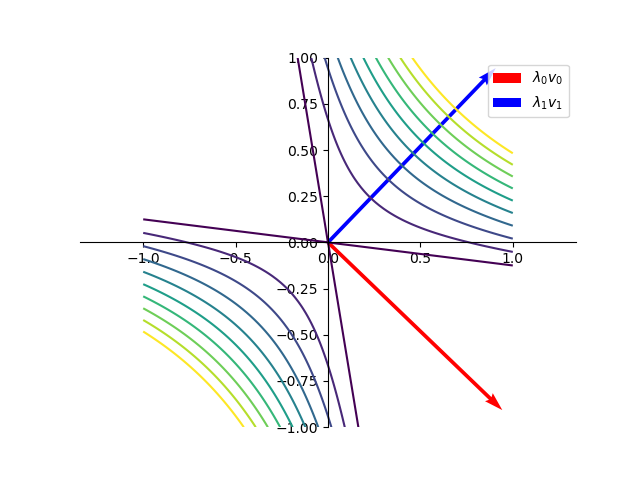

In [6]:
plt.close('all')
fig, ax = plt.subplots()
l = np.sqrt(np.real(lambda_[0])**2 + np.real(lambda_[1])**2)
print(np.real(lambda_[0])/l)
print(np.real(lambda_[1])/l)
ax.quiver([0,],[0],[np.real(lambda_[0])*v[0][0]/l], [np.real(lambda_[0])*v[1][0]/l], color = 'red', scale = 1, label = r'$\lambda_0 v_0$')
ax.quiver([0,],[0],[np.real(lambda_[0])*v[0][1]/l], [np.real(lambda_[0])*v[1][1]/l], color = 'blue', scale = 1, label = r'$\lambda_1 v_1$')
ax.legend()

def F(x,y):
    u = np.array([x,y])
    return np.dot(A@u,u)
N = 101
X = np.linspace(-1,1,N)
Y = X
x,y = np.meshgrid(X,Y)
FF = np.empty( (N,N) )
for i in np.ndindex(N,N):
    FF[i] = F(x[i],y[i])
ax.contour(x,y,FF, levels = np.linspace(0, np.max(np.real(lambda_)),10))
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.axis('equal')


### Example 2 Hermitte interpolation (the wrong way!)

Given two points $a$ and $b$, and 4 reals $p_0, q_0, p_1, q_1$, build a polynomial $P$ of degree 3 such that
$P(a) = p_0$, $P'(a) = q_0$, $P(b) = p_1$, and $P'(b) = q_1$.

interactive(children=(FloatSlider(value=0.0, description='p0', max=1.0, min=-1.0), FloatSlider(value=0.0, desc…

<function __main__.<lambda>(p0, p1, q0, q1)>

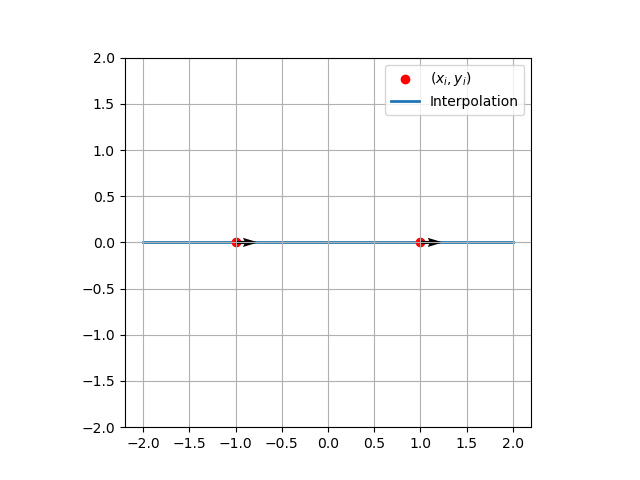

In [7]:
from numpy.polynomial import Polynomial
from ipywidgets import interact


rng = np.random.default_rng()

fig, ax = plt.subplots()
def plotHermitte(a, b,p0,p1,q0,q1):
    ax.cla()
    X = np.array([a, b])
    Y = np.array([p0,p1,q0,q1])
    M = np.empty((4,4))
    for i in range(2):
        M[i] = [X[i]**p for p in range(4)]
        M[i+2] = [p * X[i]**(p-1) for p in range(4)]
    H = Polynomial(np.linalg.solve(M,Y))

    ax.scatter(X,Y[0:2],color='red',label = r'$(x_i,y_i)$',zorder = 1)
    ax.quiver(X, Y[0:2], [1,1], Y[2:4])
    x = np.linspace(a- (b-a)/2,b + (b-a)/2,101)
    ax.plot(x,H(x), linewidth=2, label = 'Interpolation',zorder = 0)
    ax.set_aspect('equal', 'box')
    ax.set_ylim([-2,2])
    ax.legend(loc=0)
    ax.grid()
a = -1.
b = 1.
interact(lambda p0, p1, q0, q1 :plotHermitte(a,b, p0, p1, q0, q1), p0 = (-1,1,0.1),p1 = (-1,1,0.1), q0 = (-5,5,0.1), q1 = (-5,5,0.1))